In [ ]:
#LAB NormalObjects - Strict Complaint Processor
#Cindy Lund

In [1]:
!pip install -U langgraph langchain-core python-dotenv

  Using cached langgraph-1.0.9-py3-none-any.whl.metadata (7.4 kB)
  Using cached langchain_core-1.2.16-py3-none-any.whl.metadata (4.4 kB)
  Using cached langgraph_prebuilt-1.0.8-py3-none-any.whl.metadata (5.2 kB)
Using cached langgraph-1.0.9-py3-none-any.whl (158 kB)
Using cached langgraph_prebuilt-1.0.8-py3-none-any.whl (35 kB)
Using cached langchain_core-1.2.16-py3-none-any.whl (502 kB)

  Attempting uninstall: langchain-core

    Found existing installation: langchain-core 1.2.14

    Uninstalling langchain-core-1.2.14:

      Successfully uninstalled langchain-core-1.2.14

   ---------------------------------------- 0/3 [langchain-core]
   ---------------------------------------- 0/3 [langchain-core]
   ---------------------------------------- 0/3 [langchain-core]
   ---------------------------------------- 0/3 [langchain-core]
   ---------------------------------------- 0/3 [langchain-core]
   ---------------------------------------- 0/3 [langchain-core]
   -----------------------

In [4]:
!pip install -U langchain-openai

In [25]:
#For graph visualization in Jupyter, we can use grandalf
!pip install -U grandalf

In [ ]:
#Load environment variables from .env file (e.g. for OpenAI API key)
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

load_dotenv()

llm = ChatOpenAI(
    model="gpt-4.1-mini",   # good default; can be gpt-4o-mini if your class uses it
    temperature=0           # important for consistent categorization
)

In [22]:
# Step 1: Define the state TypedDict
from __future__ import annotations

from typing import TypedDict, Literal, Optional, List, Dict, Any
from datetime import datetime, timedelta, timezone
import hashlib


Category = Literal["portal", "monster", "psychic", "environmental", "other"]
Effectiveness = Literal["high", "medium", "low"]
StepName = Literal["intake", "validate", "investigate", "resolve", "close"]


class ComplaintState(TypedDict, total=False):
    # === Inputs ===
    raw_complaint: str
    submitted_at: str
    complainant: Optional[str]

    # === Identity / tracking ===
    complaint_id: str
    complaint_hash: str
    linked_complaint_id: Optional[str]
    is_duplicate: bool

    # === Intake outputs ===
    category: Category
    details: Dict[str, Any]
    missing_essential: List[str]
    needs_clarification: bool

    # === Validation outputs ===
    is_valid: bool
    validation_errors: List[str]
    escalated_manual_review: bool

    # === Investigation outputs ===
    investigation_ready: bool
    evidence: List[str]
    investigation_report: str

    # === Resolution outputs ===
    resolution_applied: bool
    resolution_plan: str
    effectiveness: Effectiveness
    escalated_specialist_team: bool

    # === Closure outputs ===
    closure_confirmed: bool
    satisfaction_attempted: bool
    satisfaction_result: Optional[str]
    closed_at: Optional[str]
    follow_up_required: bool
    follow_up_due_at: Optional[str]

    # === Audit trail ===
    current_step: StepName
    history: List[StepName]
    logs: List[str]


# ---- Minimal helpers for Step 1 ----

def now_iso() -> str:
    return (
        datetime.now(timezone.utc)
        .replace(microsecond=0)
        .isoformat()
        .replace("+00:00", "Z")
    )


def make_complaint_id(raw: str, submitted_at: str) -> str:
    base = f"{submitted_at}::{raw}".encode("utf-8")
    return hashlib.sha256(base).hexdigest()[:12]


def complaint_fingerprint(complainant: Optional[str], raw: str) -> str:
    key = (complainant or "anonymous").strip().lower()
    norm = " ".join(raw.strip().lower().split())
    base = f"{key}::{norm}".encode("utf-8")
    return hashlib.sha256(base).hexdigest()

In [6]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

load_dotenv()

llm = ChatOpenAI(
    model="gpt-4.1-mini",   # good default; can be gpt-4o-mini if your class uses it
    temperature=0           # important for consistent categorization
)

In [23]:
#Step 2: Define Workflow Nodes (including LLM-based categorization in intake)
import re
from datetime import datetime, timedelta, timezone

# -----------------------------
# Simple in-memory "complaint log" for dedupe + closure logging
# (In real apps: database)
# -----------------------------
COMPLAINT_REGISTRY: List[Dict[str, Any]] = []

def log_line(state: ComplaintState, msg: str) -> None:
    state.setdefault("logs", [])
    ts = now_iso()
    line = f"{ts} | {msg}"
    state["logs"].append(line)
    print(line)  # optional for live debugging


def push_step(state: ComplaintState, step: StepName) -> None:
    state["current_step"] = step
    state.setdefault("history", [])
    state["history"].append(step)


def parse_essentials(raw: str) -> Dict[str, Any]:
    """
    Deterministic parsing heuristics.
    We do NOT need perfect NLP. We just need consistent extraction and
    identification of missing essentials (who/what/when/where).
    """
    text = raw.strip()

    # who: "I am NAME", "This is NAME", "My name is NAME"
    who = None
    m = re.search(r"\b(my name is|this is|i am)\s+([A-Z][a-zA-Z\-']+)", text)
    if m:
        who = m.group(2)

    # when: look for explicit date-like or time-like tokens
    when = None
    date_patterns = [
        r"\b\d{4}-\d{2}-\d{2}\b",               # 2026-02-26
        r"\b\d{1,2}[./]\d{1,2}[./]\d{2,4}\b",   # 26.02.2026 / 26/02/26
        r"\b(last night|yesterday|today|this morning|two days ago)\b",
        r"\b\d{1,2}:\d{2}\b",                   # 14:30
    ]
    for pat in date_patterns:
        m = re.search(pat, text, flags=re.IGNORECASE)
        if m:
            when = m.group(0)
            break

    # where: crude but deterministic – "at/in/near LOCATION"
    where = None
    m = re.search(r"\b(?:at|in|near)\s+([A-Z][\w\-\s']{2,40})", text)
    if m:
        where = m.group(1).strip()

    # what: if complaint has any verb-ish action, use full text as "what" summary;
    # otherwise leave missing.
    what = None
    if len(text) >= 20:
        what = text

    return {"who": who, "when": when, "where": where, "what": what}


def categorize(raw: str) -> Category:
    """
    LLM-based categorization (teacher-style) with strict guardrails:

    - Must return exactly one of the 5 categories
    - If the LLM returns anything unexpected, fall back to deterministic keyword rules
    """
    allowed: set[str] = {"portal", "monster", "psychic", "environmental", "other"}

    prompt = f"""Categorize this Downside Up complaint into exactly ONE of these categories:
- portal: Issues with portal timing, location, or behavior
- monster: Issues with creature behavior (demogorgons, etc.)
- psychic: Issues with psychic abilities or limitations
- environmental: Issues with electricity, weather, or physical environment
- other: Anything else

Complaint:
{raw}

Respond with ONLY one word from: portal, monster, psychic, environmental, other.
"""

    try:
        response = llm.invoke([HumanMessage(content=prompt)])
        category = (response.content or "").strip().lower()
        if category in allowed:
            return category  # type: ignore[return-value]
    except Exception:
        pass

    # -------- Deterministic fallback --------
    t = raw.lower()
    portal_kw = ["portal", "rift", "gate", "tear", "opening", "wormhole", "time slip", "time loop", "glow", "flicker"]
    monster_kw = ["monster", "demogorgon", "creature", "claws", "teeth", "stalked", "attacked", "growl", "slime"]
    psychic_kw = ["psychic", "telekinesis", "telepathy", "mind", "vision", "precognition", "powers", "ability", "nosebleed"]
    env_kw = ["electric", "power", "outage", "lights", "storm", "weather", "thunder", "ozone", "temperature", "static"]

    if any(k in t for k in portal_kw):
        return "portal"
    if any(k in t for k in monster_kw):
        return "monster"
    if any(k in t for k in psychic_kw):
        return "psychic"
    if any(k in t for k in env_kw):
        return "environmental"
    return "other"


def find_duplicate(complainant: Optional[str], fingerprint: str, submitted_at_iso: str) -> Optional[str]:
    """
    Duplicate = same fingerprint from same complainant within 30 days.
    We store entries in COMPLAINT_REGISTRY with submitted_at and complaint_hash.
    """
    try:
        submitted_at = datetime.fromisoformat(submitted_at_iso.replace("Z", ""))
    except Exception:
        submitted_at = datetime.utcnow()

    cutoff = submitted_at - timedelta(days=30)

    for entry in reversed(COMPLAINT_REGISTRY):
        try:
            ts = datetime.fromisoformat(entry["submitted_at"].replace("Z", ""))
        except Exception:
            continue
        if ts < cutoff:
            break
        if entry.get("complaint_hash") == fingerprint and entry.get("complainant") == (complainant or "anonymous"):
            return entry.get("complaint_id")
    return None


# -----------------------------
# Node 1: Intake
# -----------------------------
def intake_node(state: ComplaintState) -> ComplaintState:
    """
    Intake Rules:
    - Categorize into exactly one category
    - Flag missing essentials (who/what/when/where) for clarification
    - Detect duplicate complaints within 30 days (same issue from same person)
    """
    state = dict(state)  # safe copy
    push_step(state, "intake")
    log_line(state, "[INTAKE] Starting intake parsing & categorization.")

    raw = state.get("raw_complaint", "").strip()
    if not raw:
        state["details"] = {"who": None, "what": None, "when": None, "where": None}
        state["missing_essential"] = ["who", "what", "when", "where"]
        state["needs_clarification"] = True
        state["category"] = "other"
        state["submitted_at"] = state.get("submitted_at", now_iso())
    else:
        state["submitted_at"] = state.get("submitted_at", now_iso())
        details = parse_essentials(raw)
        state["details"] = details

        missing = [k for k in ["who", "what", "when", "where"] if not details.get(k)]
        state["missing_essential"] = missing
        state["needs_clarification"] = len(missing) > 0

        cat = categorize(raw)
        state["category"] = cat
        log_line(state, "[INTAKE] Category assigned using LLM (guardrailed).")  # optional but great for audit

    complainant = state.get("complainant") or state["details"].get("who") or "anonymous"
    state["complainant"] = complainant

    # ids + dedupe
    cid = make_complaint_id(state.get("raw_complaint", ""), state["submitted_at"])
    fp = complaint_fingerprint(complainant, state.get("raw_complaint", ""))
    state["complaint_id"] = cid
    state["complaint_hash"] = fp

    dup_id = find_duplicate(complainant, fp, state["submitted_at"])
    state["is_duplicate"] = dup_id is not None
    state["linked_complaint_id"] = dup_id

    if state["is_duplicate"]:
        log_line(state, f"[INTAKE] Duplicate detected. Linked to complaint_id={dup_id}. Consolidate.")
    log_line(state, f"[INTAKE] Category={state['category']}. Missing={state['missing_essential']}.")

    return state


# -----------------------------
# Node 2: Validate
# -----------------------------
def validate_node(state: ComplaintState) -> ComplaintState:
    state = dict(state)
    push_step(state, "validate")
    log_line(state, "[VALIDATE] Validating complaint against Bloyce rules.")

    cat: Category = state.get("category", "other")
    raw = state.get("raw_complaint", "").lower()
    details = state.get("details", {})

    errors: List[str] = []
    escalated_manual = False

    if state.get("needs_clarification"):
        errors.append(f"Missing essential details: {', '.join(state.get('missing_essential', []))}")

    if cat == "portal":
        has_location = bool(details.get("where")) or any(k in raw for k in ["at ", "in ", "near "])
        has_timing = bool(details.get("when")) or any(k in raw for k in ["time", "timing", "late", "early", "loop", "yesterday", "today", "last night"])
        if not (has_location or has_timing):
            errors.append("Portal complaint must reference specific location or timing anomaly.")
    elif cat == "monster":
        if not any(k in raw for k in ["attacked", "chased", "growl", "bit", "claw", "stalk", "interaction", "followed", "screech"]):
            errors.append("Monster complaint requires description of creature behavior or interaction.")
    elif cat == "psychic":
        if not any(k in raw for k in ["can't", "unable", "failed", "malfunction", "blocked", "limit", "weakened", "misfire", "backfire"]):
            errors.append("Psychic complaint must reference specific ability limitation or malfunction.")
    elif cat == "environmental":
        if not any(k in raw for k in ["power", "outage", "lights", "electric", "storm", "thunder", "temperature", "ozone", "static", "flicker"]):
            errors.append("Environmental complaint must connect to electricity, weather, or observable physical phenomena.")
    elif cat == "other":
        escalated_manual = True
        log_line(state, "[VALIDATE] Category=other => escalated for manual review.")

    is_valid = len(errors) == 0 and not escalated_manual
    state["validation_errors"] = errors
    state["escalated_manual_review"] = escalated_manual
    state["is_valid"] = is_valid
    state["investigation_ready"] = is_valid

    if is_valid:
        log_line(state, "[VALIDATE] Validation PASSED.")
    else:
        if escalated_manual:
            log_line(state, "[VALIDATE] Validation requires MANUAL REVIEW. Investigation blocked.")
        else:
            log_line(state, f"[VALIDATE] Validation FAILED: {errors}")

    return state


# -----------------------------
# Node 3: Investigate
# -----------------------------
def investigate_node(state: ComplaintState) -> ComplaintState:
    state = dict(state)
    push_step(state, "investigate")
    log_line(state, "[INVESTIGATE] Starting investigation.")

    if not state.get("investigation_ready"):
        state["evidence"] = []
        state["investigation_report"] = "Investigation blocked: validation not successful."
        log_line(state, "[INVESTIGATE] Blocked (validation not successful).")
        return state

    cat: Category = state["category"]
    details = state.get("details", {})
    where = details.get("where") or "unspecified location"
    when = details.get("when") or "unspecified time"

    evidence: List[str] = []
    report_lines: List[str] = []

    if cat == "portal":
        evidence.append(f"Checked temporal pattern reports around {when}.")
        evidence.append(f"Compared portal activity map consistency near {where}.")
        evidence.append("Reviewed nearby environmental sensor anomalies for correlation.")
        report_lines.append("Portal investigation focused on timing/location anomalies and correlations.")
    elif cat == "monster":
        evidence.append("Collected witness description of behavior and interaction pattern.")
        evidence.append(f"Logged incident context at {where} around {when}.")
        evidence.append("Reviewed known environmental triggers (sound, light, power fluctuations).")
        report_lines.append("Monster investigation gathered behavior data and trigger patterns.")
    elif cat == "psychic":
        evidence.append("Documented reported ability specification and failure mode.")
        evidence.append("Compared against known tested limitations under similar conditions.")
        evidence.append(f"Captured contextual factors (location={where}, time={when}).")
        report_lines.append("Psychic investigation documented limitations/malfunctions with context.")
    elif cat == "environmental":
        evidence.append(f"Pulled power line / grid activity logs near {where}.")
        evidence.append(f"Checked atmospheric conditions reports around {when}.")
        evidence.append("Analyzed anomaly correlation with known Downside Up signatures.")
        report_lines.append("Environmental investigation analyzed electricity/weather/physical phenomena.")
    else:
        evidence.append("No automated investigation available for category=other.")
        report_lines.append("Manual review required.")

    state["evidence"] = evidence
    state["investigation_report"] = " ".join(report_lines)

    log_line(state, f"[INVESTIGATE] Evidence collected: {len(evidence)} items.")
    return state


# -----------------------------
# Node 4: Resolve
# -----------------------------
def resolve_node(state: ComplaintState) -> ComplaintState:
    state = dict(state)
    push_step(state, "resolve")
    log_line(state, "[RESOLVE] Creating and applying resolution plan.")

    evidence = state.get("evidence", [])
    if not state.get("investigation_ready") or not evidence:
        state["resolution_applied"] = False
        state["resolution_plan"] = "Resolution blocked: no documented investigation results."
        state["effectiveness"] = "low"
        state["escalated_specialist_team"] = False
        log_line(state, "[RESOLVE] Blocked (missing investigation evidence).")
        return state

    cat: Category = state["category"]

    specialist = False
    plan = ""
    effectiveness: Effectiveness = "medium"

    if cat == "portal":
        plan = (
            "Applied Downside Up Protocol P-17 (Portal Stabilization): "
            "set perimeter markers, schedule 72-hour timing watch, "
            "deploy phase-lock anchors at reported coordinates."
        )
        effectiveness = "high"
    elif cat == "monster":
        plan = (
            "Applied Downside Up Protocol M-09 (Creature Deterrence & Containment): "
            "trigger-based lure diversion, establish safe corridor signage, "
            "coordinate with Field Containment Unit for patrol sweep."
        )
        specialist = True
        effectiveness = "medium"
    elif cat == "psychic":
        plan = (
            "Applied Downside Up Protocol Y-04 (Psychic Calibration): "
            "run limitation test battery, apply dampening/boost controls, "
            "retrain response thresholds under supervised conditions."
        )
        effectiveness = "medium"
    elif cat == "environmental":
        plan = (
            "Applied Downside Up Protocol E-12 (Grid & Atmospherics Mitigation): "
            "install surge isolators, coordinate temporary reroute, "
            "monitor anomaly sensors during next weather cycle."
        )
        specialist = True
        effectiveness = "medium"
    else:
        plan = "Manual review required (category=other)."
        effectiveness = "low"

    state["resolution_applied"] = True
    state["resolution_plan"] = plan
    state["effectiveness"] = effectiveness
    state["escalated_specialist_team"] = specialist

    log_line(state, f"[RESOLVE] Applied. effectiveness={effectiveness}. specialist={specialist}.")
    return state


# -----------------------------
# Node 5: Close
# -----------------------------
def close_node(state: ComplaintState) -> ComplaintState:
    state = dict(state)
    push_step(state, "close")
    log_line(state, "[CLOSE] Attempting closure.")

    applied = state.get("resolution_applied", False)
    if not applied:
        state["closure_confirmed"] = False
        state["satisfaction_attempted"] = False
        state["satisfaction_result"] = None
        state["closed_at"] = None
        state["follow_up_required"] = False
        state["follow_up_due_at"] = None
        log_line(state, "[CLOSE] Closure blocked: resolution not applied.")
        return state

    state["closure_confirmed"] = True
    state["satisfaction_attempted"] = True
    state["satisfaction_result"] = "no_response"

    closed_at = now_iso()
    state["closed_at"] = closed_at

    follow_up = state.get("effectiveness") == "low"
    state["follow_up_required"] = follow_up
    if follow_up:
        due = (
        datetime.now(timezone.utc) + timedelta(days=30)
        ).replace(microsecond=0).isoformat().replace("+00:00", "Z")
        state["follow_up_due_at"] = due
        log_line(state, f"[CLOSE] Follow-up scheduled for {due}.")
    else:
        state["follow_up_due_at"] = None

    COMPLAINT_REGISTRY.append(
        {
            "complaint_id": state.get("complaint_id"),
            "complainant": state.get("complainant", "anonymous"),
            "complaint_hash": state.get("complaint_hash"),
            "submitted_at": state.get("submitted_at"),
            "category": state.get("category"),
            "resolution": state.get("resolution_plan"),
            "outcome": state.get("satisfaction_result"),
            "closed_at": state.get("closed_at"),
        }
    )

    log_line(state, "[CLOSE] Complaint closed and logged.")
    return state

In [14]:
#Step 3 Build the Graph
from langgraph.graph import StateGraph, END

# -----------------------------
# Routing helpers (conditional edges)
# -----------------------------
def route_after_intake(state: ComplaintState) -> str:
    """
    After intake:
    - If duplicate: stop here (consolidation would happen outside this run)
    - If missing essentials: stop here (clarification requested)
    - Otherwise: proceed to validate
    """
    if state.get("is_duplicate"):
        log_line(state, "[ROUTE] Duplicate -> stopping for consolidation.")
        return END
    if state.get("needs_clarification"):
        log_line(state, "[ROUTE] Needs clarification -> stopping until details provided.")
        return END
    return "validate"


def route_after_validate(state: ComplaintState) -> str:
    """
    After validate:
    - If escalated manual review: stop
    - If not valid: stop (request clarification)
    - If valid: proceed to investigate
    """
    if state.get("escalated_manual_review"):
        log_line(state, "[ROUTE] Manual review required -> stopping.")
        return END
    if not state.get("is_valid"):
        log_line(state, "[ROUTE] Validation failed -> stopping for clarification.")
        return END
    return "investigate"


def route_after_investigate(state: ComplaintState) -> str:
    """
    After investigate:
    - If no evidence: stop (shouldn't happen if investigation_ready True, but guard anyway)
    - Else proceed to resolve
    """
    if not state.get("evidence"):
        log_line(state, "[ROUTE] No evidence -> stopping (cannot resolve).")
        return END
    return "resolve"


def route_after_resolve(state: ComplaintState) -> str:
    """
    After resolve:
    - If resolution not applied: stop
    - Else proceed to close
    """
    if not state.get("resolution_applied"):
        log_line(state, "[ROUTE] Resolution not applied -> stopping.")
        return END
    return "close"


# -----------------------------
# Step 3: Build the graph
# -----------------------------
workflow = StateGraph(ComplaintState)

# Add all nodes
workflow.add_node("intake", intake_node)
workflow.add_node("validate", validate_node)
workflow.add_node("investigate", investigate_node)
workflow.add_node("resolve", resolve_node)
workflow.add_node("close", close_node)

# Entry point
workflow.set_entry_point("intake")

# Edges (conditional + linear)
workflow.add_conditional_edges(
    "intake",
    route_after_intake,
    {
        "validate": "validate",
        END: END,
    },
)

workflow.add_conditional_edges(
    "validate",
    route_after_validate,
    {
        "investigate": "investigate",
        END: END,
    },
)

workflow.add_conditional_edges(
    "investigate",
    route_after_investigate,
    {
        "resolve": "resolve",
        END: END,
    },
)

workflow.add_conditional_edges(
    "resolve",
    route_after_resolve,
    {
        "close": "close",
        END: END,
    },
)

# Close always ends
workflow.add_edge("close", END)

# Compile the graph
app = workflow.compile()

In [24]:
# Step 4: Test the Workflow
test_complaints = [
    "The Downside Up portal opens at different times each day. How do I predict when?",
    "Demogorgons sometimes work together and sometimes fight. What's their deal?",
    "El can move things with her mind but can't lift heavy rocks. Why?",
    "Why do creatures and power lines react so strangely together?",
    "This is not a valid complaint about something random"  # Should be rejected / manual review
]

print("\nTesting workflow with sample complaints...\n")

for i, complaint_text in enumerate(test_complaints, start=1):
    print("=" * 80)
    print(f"TEST #{i}")
    print(f"Complaint: {complaint_text}")

    # Initial state (matches your TypedDict fields)
    initial_state: ComplaintState = {
        "raw_complaint": complaint_text,
        # Optional: if you want to simulate known complainants for dedupe
        # "complainant": f"tester_{i}",
    }

    # Run the workflow
    final_state: ComplaintState = app.invoke(initial_state)
    show_execution_path(final_state)

    # --- High-level result summary ---
    print("\n--- RESULT SUMMARY ---")
    print(f"complaint_id: {final_state.get('complaint_id')}")
    print(f"category: {final_state.get('category')}")
    print(f"needs_clarification: {final_state.get('needs_clarification')}")
    print(f"missing_essential: {final_state.get('missing_essential')}")
    print(f"is_duplicate: {final_state.get('is_duplicate')} (linked: {final_state.get('linked_complaint_id')})")

    print(f"is_valid: {final_state.get('is_valid')}")
    print(f"escalated_manual_review: {final_state.get('escalated_manual_review')}")
    print(f"validation_errors: {final_state.get('validation_errors')}")

    print(f"investigation_ready: {final_state.get('investigation_ready')}")
    print(f"evidence_count: {len(final_state.get('evidence', []))}")
    print(f"resolution_applied: {final_state.get('resolution_applied')}")
    print(f"effectiveness: {final_state.get('effectiveness')}")
    print(f"closure_confirmed: {final_state.get('closure_confirmed')}")
    print(f"follow_up_required: {final_state.get('follow_up_required')}")
    print(f"follow_up_due_at: {final_state.get('follow_up_due_at')}")

    print(f"history: {final_state.get('history')}")
    print(f"current_step: {final_state.get('current_step')}")

    # --- Optional: show key text outputs ---
    if final_state.get("investigation_report"):
        print("\nInvestigation report:")
        print(final_state["investigation_report"])

    if final_state.get("resolution_plan"):
        print("\nResolution plan:")
        print(final_state["resolution_plan"])

    # --- Full trace logs (shows node-by-node execution) ---
    print("\n--- TRACE LOGS ---")
    for line in final_state.get("logs", []):
        print(line)

print("\nDone.\n")


Testing workflow with sample complaints...

TEST #1
Complaint: The Downside Up portal opens at different times each day. How do I predict when?
2026-02-26T23:29:41Z | [INTAKE] Starting intake parsing & categorization.
2026-02-26T23:29:42Z | [INTAKE] Category assigned using LLM (guardrailed).
2026-02-26T23:29:42Z | [INTAKE] Category=portal. Missing=['who', 'when', 'where'].
2026-02-26T23:29:42Z | [ROUTE] Needs clarification -> stopping until details provided.

Executed path: intake
Stop reason(s): needs clarification

Logs:
2026-02-26T23:29:41Z | [INTAKE] Starting intake parsing & categorization.
2026-02-26T23:29:42Z | [INTAKE] Category assigned using LLM (guardrailed).
2026-02-26T23:29:42Z | [INTAKE] Category=portal. Missing=['who', 'when', 'where'].
2026-02-26T23:29:42Z | [ROUTE] Needs clarification -> stopping until details provided.

--- RESULT SUMMARY ---
complaint_id: 36637e8036e1
category: portal
needs_clarification: True
missing_essential: ['who', 'when', 'where']
is_duplicate:

In [19]:
def show_execution_path(final_state: ComplaintState) -> None:
    """Show which nodes ran and why the workflow stopped."""
    history = final_state.get("history", [])
    print("\nExecuted path:", " -> ".join(history) if history else "(none)")

    reasons = []
    if final_state.get("is_duplicate"):
        reasons.append("duplicate (consolidation)")
    if final_state.get("needs_clarification"):
        reasons.append("needs clarification")
    if final_state.get("escalated_manual_review"):
        reasons.append("manual review escalation")
    if final_state.get("is_valid") is False:
        reasons.append("validation failed")
    if final_state.get("resolution_applied") is False:
        reasons.append("resolution not applied")

    print("Stop reason(s):", "; ".join(reasons) if reasons else "none (likely reached END after close)")

    print("\nLogs:")
    for line in final_state.get("logs", []):
        print(line)

In [26]:
#Step 5A — Visualize the graph structure (ASCII + Mermaid PNG)
def show_graph_structure() -> None:
    """Visualize the compiled graph structure (like the teacher example)."""
    g = app.get_graph()

    # 1) ASCII (always the safest)
    try:
        print(g.draw_ascii())
    except Exception as e:
        print("ASCII graph visualization not available:", e)

    # 2) Mermaid text (copy/paste into Mermaid viewer)
    try:
        mermaid = g.draw_mermaid()
        print("\n--- Mermaid ---\n")
        print(mermaid)
    except Exception as e:
        print("Mermaid text visualization not available:", e)

    # 3) Mermaid PNG (Jupyter-friendly)
    try:
        from IPython.display import Image, display  # type: ignore
        png_bytes = g.draw_mermaid_png()
        display(Image(png_bytes))
    except Exception as e:
        print("Mermaid PNG visualization not available in this environment:", e)

ASCII graph visualization not available: Install grandalf to draw graphs: `pip install grandalf`.

--- Mermaid ---

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	intake(intake)
	validate(validate)
	investigate(investigate)
	resolve(resolve)
	close(close)
	__end__([<p>__end__</p>]):::last
	__start__ --> intake;
	intake -.-> __end__;
	intake -.-> validate;
	investigate -.-> __end__;
	investigate -.-> resolve;
	resolve -.-> __end__;
	resolve -.-> close;
	validate -.-> __end__;
	validate -.-> investigate;
	close --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



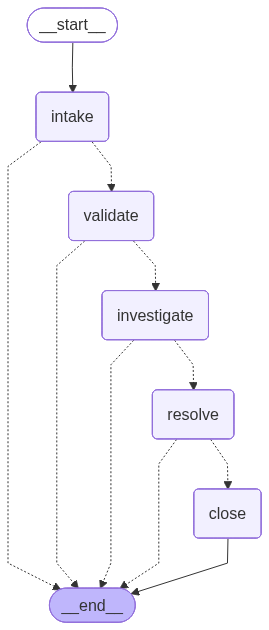

In [27]:
show_graph_structure()